<a href="https://colab.research.google.com/github/aledinola/Python_vs_Matlab/blob/main/cake_eating_numerical_ale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$
\newcommand{\argmax}{\operatorname*{argmax}}
\newcommand{\argmin}{\operatorname*{argmin}}
\newcommand{\EE}{\mathbb{E}}
$$

# Neoclassical growth model

## Contents

- [Optimal Savings II: Numerical Cake Eating](#Optimal-Savings-II:-Numerical-Cake-Eating)  
  - [Overview](#Overview)  
  - [Reviewing the Model](#Reviewing-the-Model)  
  - [Value Function Iteration](#Value-Function-Iteration)  
  - [Exercises](#Exercises)  

## Overview

In this lecture we study the neoclassical growth model (deterministic version), also called Ramsey model.

The aim of this lecture is to solve the problem using numerical methods.

Since we know the analytical solution, this will allow us to assess the
accuracy of alternative numerical methods.


We will use the following imports:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar, bisect
from typing import NamedTuple

## Reviewing the Model

Consider the neoclassical growth model with full depreciation and log utility: these two assumptions allow us to derive a closed form solution.
The Bellman equation is

<a id='equation-bellman-cen'></a>
$$
v(k) = \max_{0\leq k' \leq k^\alpha} \{u(k^\alpha-k') + \beta v(k')\}
\quad \text{for all } k \geq 0. \tag{66.1}
$$

where $ u $ is the log utility function and $ f $ is the production function $ f(k) = k^\alpha$, with $0<\alpha<1$.

The analytical solutions for the value function and optimal policy were found
to be as follows.

In [ ]:
def k_star(k, alpha, beta):
    # Policy function for next-period capital
    y = k**alpha
    return alpha*beta*y


#def v_star(x, β, γ):

#    return (1 - β**(1 / γ))**(-γ) * (x**(1-γ) / (1-γ))

Our first aim is to obtain these analytical solutions numerically.

## Value Function Iteration

The first approach we will take is **value function iteration**.

This is a form of **successive approximation**.

The basic idea is:

1. Take an arbitrary initial guess of $ v $.  
1. Obtain an update $ \hat v $ defined by  
  $$
  \hat v(k) = \max_{0\leq k' \leq f(k)} \{u(f(k)-k') + \beta v(k')\}
  $$
1. Stop if $ \hat v $ is approximately equal to $ v $, otherwise set
  $ v=\hat v $ and go back to step 2.  


Let’s write this a bit more mathematically.

### The Bellman Operator

We introduce the **Bellman operator** $ T $ that takes a function v as an
argument and returns a new function $ Tv $ defined by

$$
Tv(k) = \max_{0 \leq k' \leq f(k)} \{u(f(k)-k') + \beta v(k')\}
$$

From $ v $ we get $ Tv $, and applying $ T $ to this yields
$ T^2 v := T (Tv) $ and so on.

This is called **iterating with the Bellman operator** from initial guess
$ v $.

As we discuss in more detail in later lectures, one can use Banach’s
contraction mapping theorem to prove that the sequence of functions $ T^n
v $ converges to the solution to the Bellman equation.

### Fitted Value Function Iteration

Both next-period capital $ k' $ and the state variable $ k $ are continuous.

This causes complications when it comes to numerical work.

For example, we need to store each function $ T^n v $ in order to
compute the next iterate $ T^{n+1} v $.

But this means we have to store $ T^n v(k) $ at infinitely many $ k $, which is, in general, impossible.

To circumvent this issue we will use fitted value function iteration, as
discussed previously in [one of the lectures](https://python.quantecon.org/mccall_fitted_vfi.html) on job
search.

The process looks like this:

1. Begin with an array of values $ \{ v_0, v_1, \ldots, v_I \} $  representing
  the values of some initial function $ v $ on the grid points $ \{ k_0, k_1, \ldots, k_I \} $. Note that there $I+1$ grid points since we start from $0$.  
1. Build a function $ \hat v $ on the state space $ \mathbb R_+ $ by
  interpolation, based on the interpolation points $ \{(k_i, v_i)\} $.  
1. Insert $ \hat v $ into the right hand side of the Bellman equation and
  obtain and record the value $ T \hat v(x_i) $ on each grid point
  $ x_i $.  
1. Unless some stopping condition is satisfied, set
  $ \{ v_0, \ldots, v_I \} = \{ T \hat v(x_0), \ldots, T \hat v(x_I) \} $ and go to step 2.  


In step 2 we’ll use **piecewise linear interpolation**.

### Implementation

The `maximize` function below is a small helper function that converts a
SciPy minimization routine into a maximization routine.

In [ ]:
def maximize(g, lower_bound, upper_bound):
    """
    Maximize g over [lower_bound, upper_bound].
    """
    objective = lambda x: -g(x)
    bounds = (lower_bound, upper_bound)

    result = minimize_scalar(
        objective,
        bounds=bounds,
        method='bounded'
    )

    maximizer = result.x
    maximum = -result.fun

    return maximizer, maximum

We’ll store the parameters $ \beta $ (discount factor) in a structure called `par`. We will use `par` also to store the capital grid and other numerical parameters.

In [ ]:
class Model(NamedTuple):
    β: float
    α: float
    k_grid: np.ndarray

def create_growth_model(
        β: float = 0.96,
        α: float = 0.4,
        k_grid_min: float = 1e-3,
        k_grid_max: float = 10.0,
        k_grid_size: int = 300
    ):
    """
    Create an instance of the deterministic neoclassical growth model.
    """
    k_grid = np.linspace(k_grid_min, k_grid_max, k_grid_size)
    return Model(β, α, k_grid)

Here’s the log utility function and the Cobb-Douglas production function.

In [ ]:
def f_util(c):
    util = np.log(c)
    return util

def f_prod(k,α):
    y = k**α
    return y

To work with the Bellman equation, let’s write it as

$$
v(x) = \max_{0 \leq k' \leq f(k)} RHS(k',k,v)
$$

where

$$
RHS(k',k,v) := u(f(k)-k') + \beta v(k')
$$

Now we implement the function $ RHS $.

In [ ]:
def RHS(
        kprime: float,  # future capital
        k: float,       # current capital
        v: np.ndarray,  # current guess of the value function
        model: Model    # instance of model
    ):
    """
    Right hand side of the Bellman equation given k'.

    """
    # Unpack (simplify names)
    β, alpha, k_grid = model

    # Consumption
    c = f_prod(k,alpha)-kprime

    # Return RHS(k'). Note that in general kprime is not a point of k_grid
    # hence we have to interpolate. We use linear interpolation for simplicity.
    return f_util(c) + β * np.interp(kprime, k_grid, v)

We now define the Bellman operator acting on grid points:

$$
Tv(k_i) = \max_{0 \leq k' \leq f(k_i)} RHS(k',k_i,v)
    \qquad \text{for all } i
$$

In [ ]:
def T(
        v: np.ndarray,          # Current guess of the value function
        model: Model            # Instance of the cake eating model
    ):
    " The Bellman operator.  Updates the guess of the value function. "

    # Allocate memory for the new array v_new = Tv
    v_new = np.empty_like(v)

    # Calculate Tv(x) for all x
    for i, k in enumerate(model.k_grid):
        # Maximize RHS of Bellman equation with respect to k' over [0, f(k)]
        lower_bound = model.k_grid[0]
        upper_bound = f_prod(k, model.α) - 1e-10
        _, v_new[i] = maximize(lambda kprime: RHS(kprime, k, v, model), lower_bound,upper_bound)

    return v_new

After defining the Bellman operator, we are ready to solve the model.

Let’s start by creating a model using the default parameterization.

In [ ]:
model = create_growth_model()
β, alpha, k_grid = model

Now let’s see iteration of the value function in action.

We start from guess $ v $ given by $ v(x) = u(x) $ for every
$ x $ grid point.

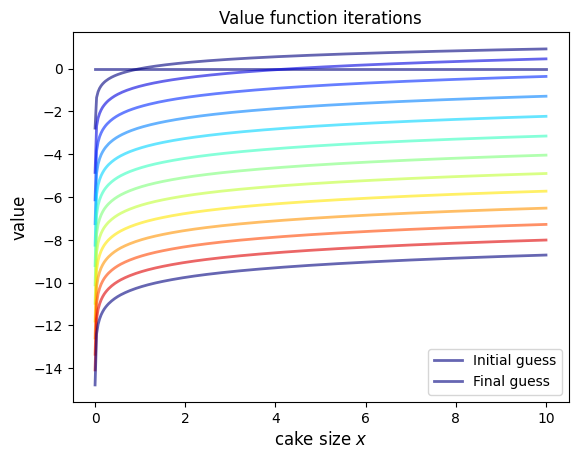

In [ ]:
from numpy._core.fromnumeric import size

v = np.zeros(len(k_grid))  # Initial guess
n = 12                     # Number of iterations
fig, ax = plt.subplots()

# Initial plot
ax.plot(k_grid, v, color=plt.cm.jet(0),
        lw=2, alpha=0.6, label='Initial guess')

# Iterate
for i in range(n):
    v = T(v, model)  # Apply the Bellman operator
    ax.plot(k_grid, v, color=plt.cm.jet(i / n), lw=2, alpha=0.6)

# One last update and plot
v = T(v, model)
ax.plot(k_grid, v, color=plt.cm.jet(0),
        lw=2, alpha=0.6, label='Final guess')

ax.legend()
ax.set_ylabel('value', fontsize=12)
ax.set_xlabel('cake size $x$', fontsize=12)
ax.set_title('Value function iterations')
plt.show()

To iterate more systematically, we introduce a wrapper function called
`compute_value_function`.

It’s task is to iterate using $ T $ until some convergence conditions are satisfied.

In [ ]:
def compute_value_function(
        model: Model,
        tol: float = 1e-4,
        max_iter: int = 1_000,
        verbose: bool = True,
        print_skip: int = 25
    ):

    # Set up loop
    v = np.zeros(len(model.k_grid)) # Initial guess
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:
        v_new = T(v, model)

        error = np.max(np.abs(v - v_new))
        i += 1

        if verbose and i % print_skip == 0:
            print(f"Error at iteration {i} is {error}.")

        v = v_new

    if error > tol:
        print("Failed to converge!")
    elif verbose:
        print(f"\nConverged in {i} iterations.")

    return v_new

Now let’s call it, noting that it takes a little while to run.

In [ ]:
v = compute_value_function(model)

Error at iteration 25 is 0.4295815984051252.
Error at iteration 50 is 0.15481983258213106.
Error at iteration 75 is 0.05579659542016202.
Error at iteration 100 is 0.02010892087949756.
Error at iteration 125 is 0.007247265681431969.
Error at iteration 150 is 0.0026118966864707716.
Error at iteration 175 is 0.000941343189150956.
Error at iteration 200 is 0.00033928835469509977.
Error at iteration 225 is 0.00012235157969797683.

Converged in 230 iterations.


Now we can plot and see what the converged value function looks like.

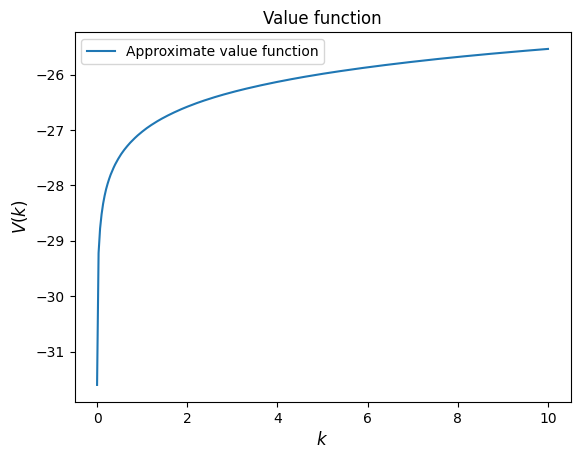

In [ ]:
fig, ax = plt.subplots()

ax.plot(k_grid, v, label='Approximate value function')
ax.set_ylabel('$V(k)$', fontsize=12)
ax.set_xlabel('$k$', fontsize=12)
ax.set_title('Value function')
ax.legend()
plt.show()

Next let’s compare it to the analytical solution.

### Policy Function

the optimal capital policy is

$$
\sigma^*(x) = \alpha \beta k^\alpha
$$

Let’s see if our numerical results lead to something similar.

Our numerical strategy will be to compute, for any given $ v $, the policy

$$
\sigma(x) = \arg \max_{0 \leq k' \leq k^\alpha} \{u(k^\alpha-k') + \beta v(k')\}
$$

This policy is called the $ v $-**greedy policy**.

In practice we will compute $ \sigma $ on a grid of $ k $ points and then interpolate.

For $ v $ we will use the approximation of the value function we obtained above.

Here’s the function:

In [ ]:
def get_greedy(
        v: np.ndarray,          # current guess of the value function
        model: Model            # instance of model
    ):
    " Compute the v-greedy policy on k_grid."

    σ = np.empty_like(v)

    for i, k in enumerate(model.k_grid):
        # Maximize RHS of Bellman equation at state k, with respect to k', over [0,y]
        # where y=f(k)
        lower_bound = model.k_grid[0]
        y = f_prod(k, model.α)
        σ[i], _ = maximize(lambda kprime: RHS(kprime, k, v, model), lower_bound, y)

    return σ

Now let’s pass the approximate value function and compute optimal consumption:

In [ ]:
σ = get_greedy(v, model)


<a id='pol-an'></a>
Let’s plot this next to the true analytical solution

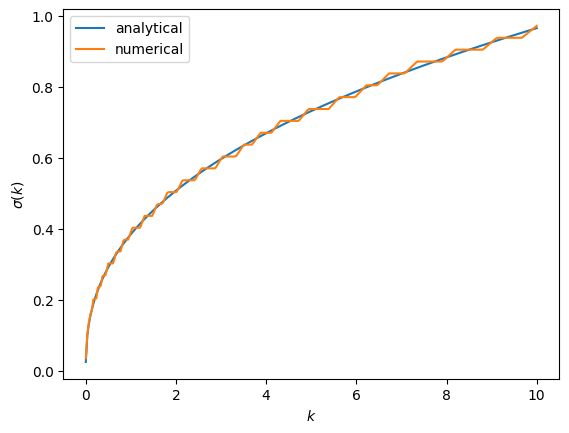

In [ ]:
kprime_analytical = k_star(model.k_grid, model.α, model.β)

fig, ax = plt.subplots()

ax.plot(model.k_grid, kprime_analytical, label='analytical')
ax.plot(model.k_grid, σ, label='numerical')
ax.set_ylabel(r'$\sigma(k)$')
ax.set_xlabel('$k$')
ax.legend()

plt.show()

The fit is reasonable but not perfect.

We can improve it by increasing the grid size or reducing the
error tolerance in the value function iteration routine.

However, both changes will lead to a longer compute time.

Another possibility is to use an alternative algorithm, which offers the
possibility of faster compute time and, at the same time, more accuracy.